# Amino-acid combinatorial library

Demonstrates `import_library` and `update_with_library` with a **4 × 4 codon matrix**:
four positions, four codon options each, every part a multiple of three bases so it
codes for a complete set of amino acids with no frame ambiguity.

| Position | Options |
|----------|---------|
| 1 — aliphatic | Gly `GGT`, Ala `GCT`, Val `GTT`, Leu `CTG` |
| 2 — polar     | Ser `TCT`, Thr `ACT`, Asn `AAT`, Gln `CAA` |
| 3 — charged   | Asp `GAT`, Glu `GAA`, Lys `AAA`, Arg `CGT` |
| 4 — aromatic  | Phe `TTT`, Tyr `TAT`, Trp `TGG`, His `CAT` |

Each combination codes for a unique tetrapeptide; 4⁴ = 256 possible sequences.

Two scenarios are covered:

1. **`import_library`** — the library is imported as a standalone sequence graph and the
   complete graph is translated.
2. **`update_with_library`** — the library is inserted into a backbone sequence and the
   full updated sequence graph (backbone + library variants) is translated.

In [1]:
import tempfile, gen

tmp = tempfile.mkdtemp()
repo = gen.Repository(tmp)

## Define the 4 × 4 part matrix

In [2]:
sp = gen.SequencePart   # shorthand

parts_list = [
    # Position 1 — aliphatic
    [sp("Gly1", "GGT"), sp("Ala1", "GCT"), sp("Val1", "GTT"), sp("Leu1", "CTG")],
    # Position 2 — polar uncharged
    [sp("Ser2", "TCT"), sp("Thr2", "ACT"), sp("Asn2", "AAT"), sp("Gln2", "CAA")],
    # Position 3 — charged
    [sp("Asp3", "GAT"), sp("Glu3", "GAA"), sp("Lys3", "AAA"), sp("Arg3", "CGT")],
    # Position 4 — aromatic / imidazole
    [sp("Phe4", "TTT"), sp("Tyr4", "TAT"), sp("Trp4", "TGG"), sp("His4", "CAT")],
]

print(f"{len(parts_list)} positions × {len(parts_list[0])} options = "
      f"{len(parts_list[0]) ** len(parts_list)} combinations")

4 positions × 4 options = 256 combinations


## 1 — `import_library`: standalone tetrapeptide library

The library is a sequence graph whose paths are all 4-codon (12 bp) combinations.
Translating the complete graph produces a protein graph where each of the four
positions branches into four amino-acid nodes.

In [ ]:
repo.import_library("tetrapeptide_lib", parts_list)

lib_sg = next(
    sg for sg in repo.get_sequence_graphs()
    if sg.name == "tetrapeptide_lib"
)
print(lib_sg)

In [ ]:
lib_sg.plot()

In [ ]:
# Translate the complete library graph — no region argument means translate_block_group
# is called, which covers all paths from start to end.
protein_lib = lib_sg.translate_annotation(output_sample="tetrapeptide_lib_protein")
print(protein_lib)

In [6]:
protein_lib.plot()

## 2 — `update_with_library`: library inserted into a backbone

The backbone is a minimal coding sequence:

```
ATG · AAAAAAAAAAAA · TAA
 M  ·  K  K  K  K  ·  *   (placeholder)
0   3              15   18
```

`update_with_library` replaces positions 3–15 with the combinatorial library.
The resulting sequence graph retains the invariant `ATG` (Met) and `TAA` (stop) flanks
while the four internal positions become the variant library nodes.

In [ ]:
import os

# Import backbone: ATG + 4×Lys placeholder + stop (18 bp)
backbone_seq = "ATG" + "AAA" * 4 + "TAA"
fasta_path = os.path.join(tmp, "backbone.fa")
with open(fasta_path, "w") as f:
    f.write(f">backbone\n{backbone_seq}\n")

repo.import_fasta(fasta_path, sample="wt")

backbone_wt = next(
    sg for sg in repo.get_sequence_graphs()
    if sg.name == "backbone" and sg.sample_name == "wt"
)
print(backbone_wt)

In [ ]:
# Replace the 12 bp Lys placeholder with the combinatorial library.
# Region string: "backbone:3-15" selects the 0-based half-open interval [3, 15).
repo.update_with_library(
    sample="wt",
    new_sample_name="lib_inserted",
    path_name="backbone:3-15",
    parts_list=parts_list,
)

backbone_lib = next(
    sg for sg in repo.get_sequence_graphs()
    if sg.sample_name == "lib_inserted"
)
print(backbone_lib)

In [10]:
backbone_lib.plot()

In [ ]:
# Translate the full updated sequence graph.
# The invariant Met and stop codon appear as single nodes; the four library
# positions each branch into four amino-acid nodes.
protein_backbone = backbone_lib.translate_annotation(
    output_sample="lib_inserted_protein"
)
print(protein_backbone)

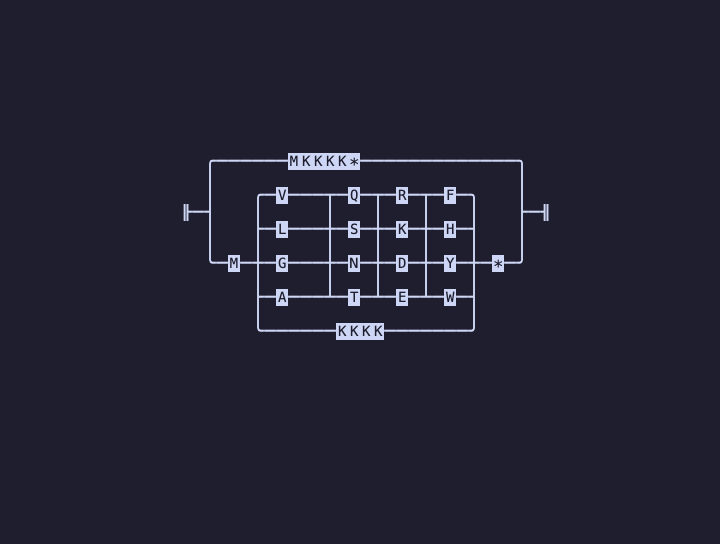

In [21]:
protein_backbone.plot(rows=32)